## Time gap

In [1]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist,squareform
import os
from nltools.mask import expand_mask, roi_to_brain
from nltools.data import Brain_Data, Adjacency


import glob
from tqdm.notebook import tqdm

current_directory = '/Storage/Data/nes_menghan/code_menghan/NeuroExperience/'
svg_file = 'svg_files' ## svg plots

In [2]:
base_dir = '/Storage/Data/nes_menghan/liquidsword2_materials/behavioral_stability'
time_all = os.path.join(base_dir,'NES_subject_log.xlsx')
time_all = pd.read_excel(time_all,sheet_name='Spring_2019')
time_all

,subNum,sessionNum,Researcher,Date,Time,Name,Sex,DOB,Age,Age.1,Weight,Height,Ht (inches),BMI,Accession Num,Scan SID,Notes,Amt Paid,OnBase bonus payment #,Unnamed: 19
0,40.0,1.0,AB,2019-10-13,11:00:00,Sajid Ahsan,m,1997-11-20,"21 Years, 10 Months, 23 Days",21.000000,150.0,5'10,70.0,21.520408,A003014,SID000381,NaN,60,prescription -7.0,NaN
1,40.0,2.0,AB,2019-10-20,13:00:00,Sajid Ahsan,m,1997-11-20,"21 Years, 11 Months, 0 Days",21.000000,150.0,5'10,70.0,21.520408,A003051,SID000381,NaN,60,prescription -7.0,NaN
2,40.0,3.0,AB,2019-10-27,13:00:00,Sajid Ahsan,m,1997-11-20,"21 Years, 11 Months, 7 Days",21.000000,150.0,5'10,70.0,21.520408,A003080,SID000381,NaN,60,prescription -7.0,NaN
3,40.0,4.0,AB,2019-11-09,16:30:00,Sajid Ahsan,m,1997-11-20,"21 Years, 11 Months, 20 Days",21.000000,150.0,5'10,70.0,21.520408,A003134,SID000381,NaN,60,prescription -7.0,NaN
4,40.0,5.0,AB,2019-11-17,13:30:00,Sajid Ahsan,m,1997-11-20,"21 Years, 11 Months, 28 Days",21.000000,150.0,5'10,70.0,21.520408,A003160,SID000381,coughing,60,652281,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,NaN,NaN,NaN,2019-10-26,NaN,Paridhi Kapadia,NaN,2002-09-02,"17 Years, 1 Months, 24 Days",17.000000,NaN,NaN,NaN,NaN,NaN,NaN,couldn't scan as they were under 18,1 Tpt,NaN,NaN
186,58.0,1.0,AB,2019-11-07,17:30:00,Sophie Kodak,NaN,2001-08-11,"18 Years, 2 Months, 27 Days",NaN,NaN,NaN,NaN,#DIV/0!,NaN,NaN,couldn't scan due to rza update errors,1 Tpt,NaN,NaN
187,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,23.456989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaN,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
time_all_select = time_all.loc[:,['subNum','sessionNum','Date','Time','Accession Num','Scan SID']]
time_all_select



,subNum,sessionNum,Date,Time,Accession Num,Scan SID
0,40.0,1.0,2019-10-13,11:00:00,A003014,SID000381
1,40.0,2.0,2019-10-20,13:00:00,A003051,SID000381
2,40.0,3.0,2019-10-27,13:00:00,A003080,SID000381
3,40.0,4.0,2019-11-09,16:30:00,A003134,SID000381
4,40.0,5.0,2019-11-17,13:30:00,A003160,SID000381
...,...,...,...,...,...,...
185,NaN,NaN,2019-10-26,NaN,NaN,NaN
186,58.0,1.0,2019-11-07,17:30:00,NaN,NaN
187,NaN,NaN,NaT,NaN,NaN,NaN
188,NaN,NaN,NaT,NaN,NaN,NaN


In [4]:
demo_all_select = time_all.loc[:,['Sex','Age.1','Scan SID']]

In [7]:
gender_all = []
age_all = []
for sub_num in range(20):
    sub_name = subj_sids_iteration[sub_num].split('sid')[1]
    sub_name = 'SID'+sub_name
    sub_demo = demo_all_select[demo_all_select['Scan SID'] == sub_name]
    gender_all.append(sub_demo.iloc[0,0])
    age_all.append(sub_demo.iloc[0,1])

In [68]:
age_all
from statistics import mean,pstdev
print(mean(age_all))
print(pstdev(age_all))

24.0
4.701063709417263


In [6]:
data_dir = '/Storage/Data/nes_menghan/preprocessed/final/'
subj_sids_list = os.listdir(data_dir)
subj_sids_iteration = []
for subj in subj_sids_list:
    subj_path = os.path.join(data_dir, subj)
    subj_path_sess = os.listdir(subj_path)
    if len(subj_path_sess) == 5:
        subj_sids_iteration.append(subj)
    
    
subj_sids_iteration.remove('sub-sid001215') ###the Timepoints of this subject's third session were fewer than others
subj_sids_iteration.remove('sub-sid001473') ### the fifth

subj_sids_iteration.remove('sub-sid000860') 
subj_sids_iteration.remove('sub-sid001201')  ### head coil issue: HEP
print(len(subj_sids_iteration))
subj_sids_iteration

20


['sub-sid001377',
 'sub-sid001277',
 'sub-sid001280',
 'sub-sid001367',
 'sub-sid000846',
 'sub-sid001274',
 'sub-sid001397',
 'sub-sid001358',
 'sub-sid001276',
 'sub-sid000381',
 'sub-sid001286',
 'sub-sid001282',
 'sub-sid000854',
 'sub-sid001555',
 'sub-sid001291',
 'sub-sid000780',
 'sub-sid001302',
 'sub-sid001296',
 'sub-sid001278',
 'sub-sid000861']

In [8]:
sub_time_gap_all = pd.DataFrame()

for sub_num in range(20):
    sub_name = subj_sids_iteration[sub_num].split('sid')[1]
    sub_name = 'SID'+sub_name
    sub_time = time_all_select[time_all_select['Scan SID'] == sub_name]
    sub_time = sub_time.dropna(axis=0,how='any')  
    sub_time.sort_values("sessionNum",inplace=True)
    
    a = 0
    
    sub_time_gap_time0 = pd.DataFrame(np.array([a,1,subj_sids_iteration[sub_num],sub_time.iloc[0,0]]).reshape(-1,1).T,columns = ['scan time','session','participants','subNum'])
    sub_time_gap_all = pd.concat([sub_time_gap_all,sub_time_gap_time0])
                                 
    for time_gap_time in range(4):
        b = (sub_time.iloc[time_gap_time+1,2]-sub_time.iloc[time_gap_time,2]).days
        a = a+b
        sub_time_gap = pd.DataFrame(np.array([a,time_gap_time+2,subj_sids_iteration[sub_num],sub_time.iloc[0,0]]).reshape(-1,1).T,columns = ['scan time','session','participants','subNum'])


        sub_time_gap_all = pd.concat([sub_time_gap_all,sub_time_gap])


In [9]:
sub_time_gap_all['subNum']=sub_time_gap_all['subNum'].astype(float)

sub_time_gap_all

,scan time,session,participants,subNum
0,0,1,sub-sid001377,25.0
0,40,2,sub-sid001377,25.0
0,47,3,sub-sid001377,25.0
0,81,4,sub-sid001377,25.0
0,88,5,sub-sid001377,25.0
...,...,...,...,...
0,0,1,sub-sid000861,7.0
0,14,2,sub-sid000861,7.0
0,21,3,sub-sid000861,7.0
0,28,4,sub-sid000861,7.0


In [87]:
time_interval = sub_time_gap_all[sub_time_gap_all['session'] == '5'][['scan time']].astype(float)/5
print(time_interval.mean())
print(time_interval.std())


scan time    11.0
dtype: float64
scan time    3.574765
dtype: float64


In [10]:
unique_subject = sub_time_gap_all['subNum'].unique().tolist()
unique_subject_int = [int(float(x)) for x in unique_subject]
unique_subject_int

[25, 4, 9, 36, 23, 1, 35, 24, 3, 40, 12, 11, 32, 41, 16, 6, 21, 18, 8, 7]

In [11]:
unique_subject_name = sub_time_gap_all['participants'].unique().tolist()
unique_subject_name

['sub-sid001377',
 'sub-sid001277',
 'sub-sid001280',
 'sub-sid001367',
 'sub-sid000846',
 'sub-sid001274',
 'sub-sid001397',
 'sub-sid001358',
 'sub-sid001276',
 'sub-sid000381',
 'sub-sid001286',
 'sub-sid001282',
 'sub-sid000854',
 'sub-sid001555',
 'sub-sid001291',
 'sub-sid000780',
 'sub-sid001302',
 'sub-sid001296',
 'sub-sid001278',
 'sub-sid000861']

## time gap

/tmp/ipykernel_2560524/1038952042.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_time_stability.sort_values("session",inplace=True)
/tmp/ipykernel_2560524/1038952042.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_time_stability.sort_values("session",inplace=True)
/tmp/ipykernel_2560524/1038952042.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_time_stability.sort_values("session",inplace=True)
/tmp/ipykernel_2

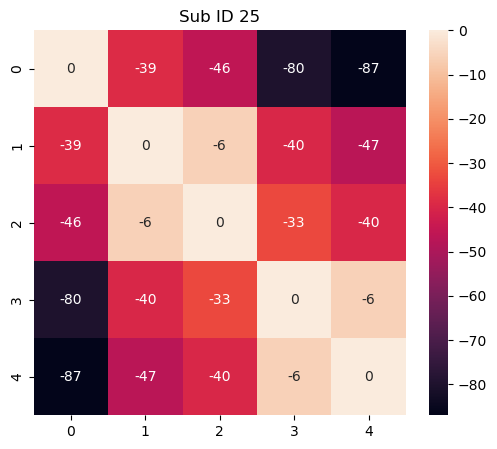

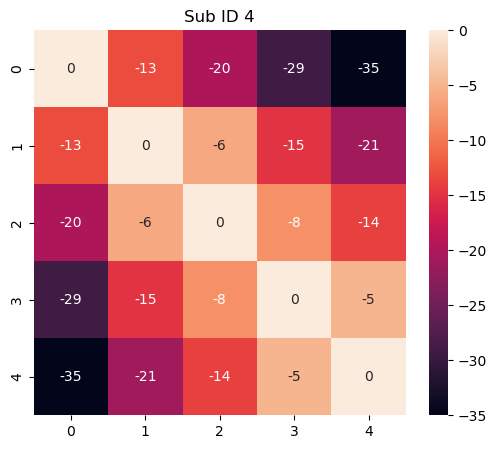

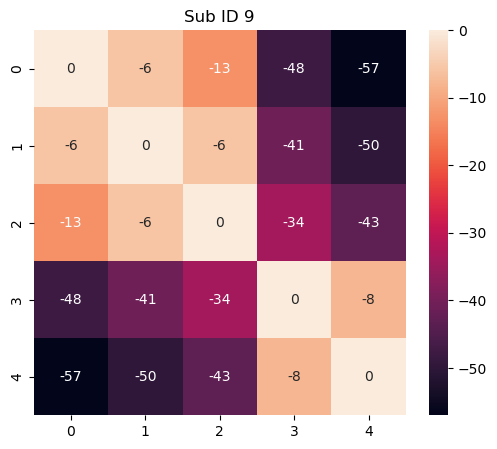

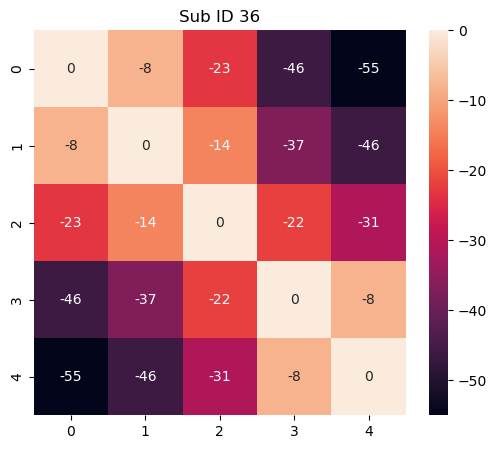

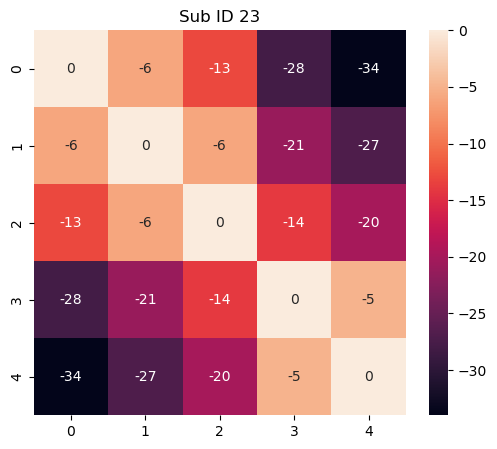

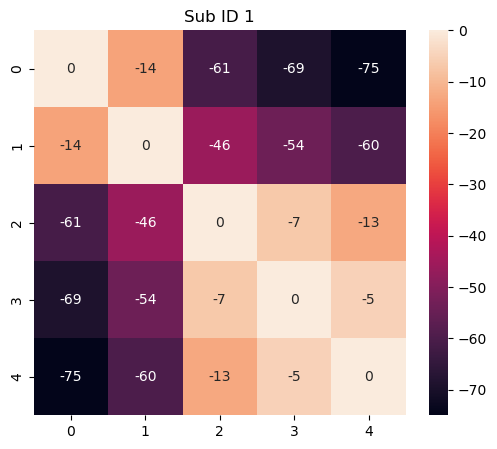

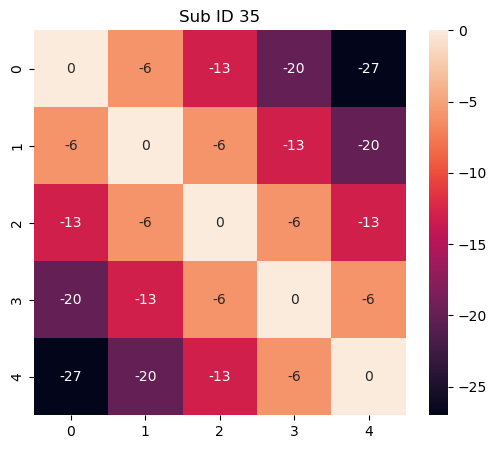

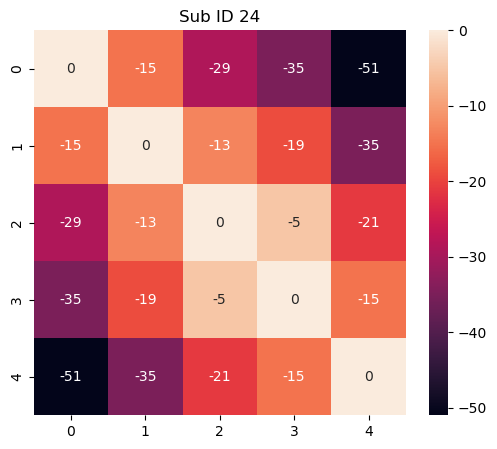

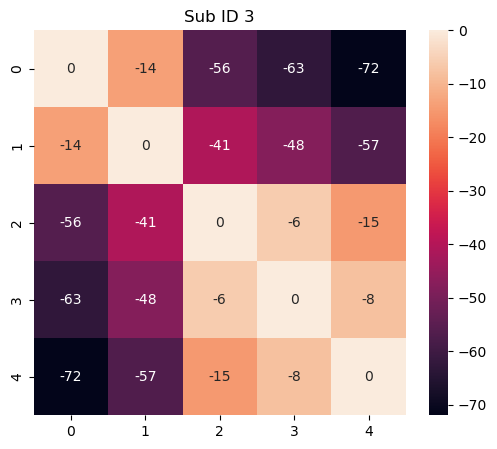

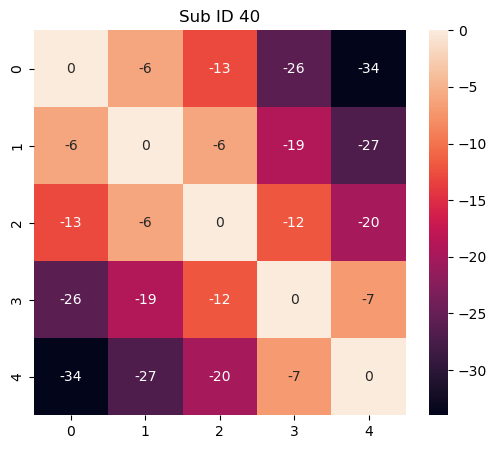

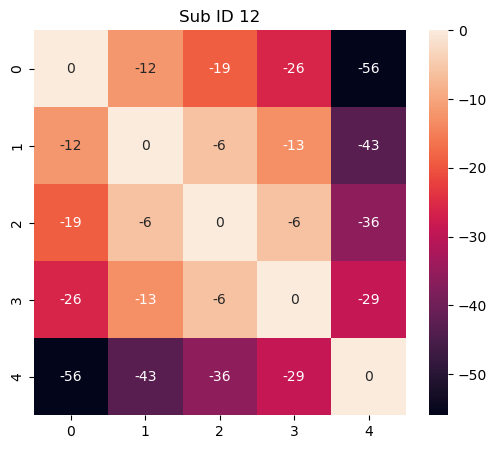

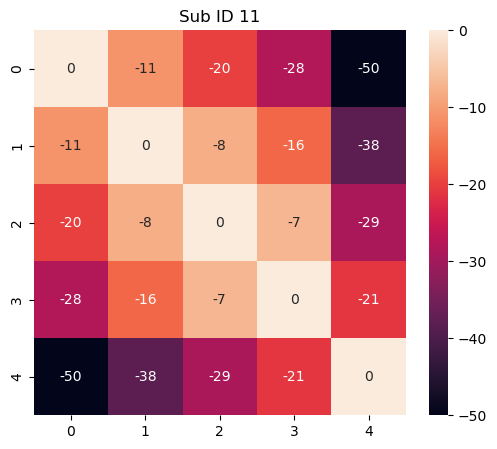

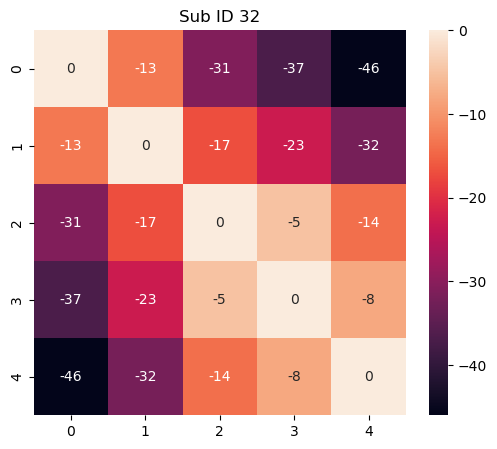

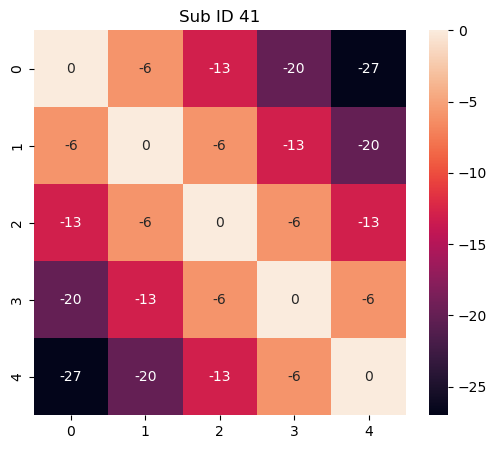

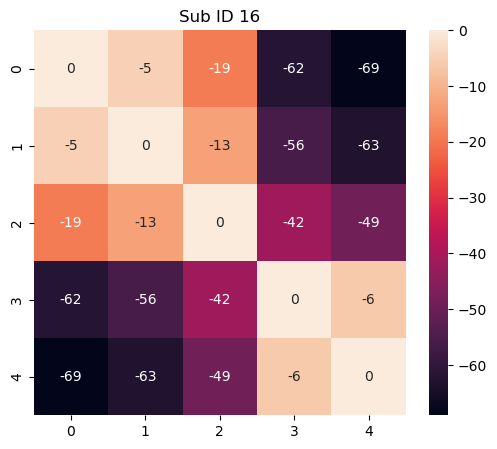

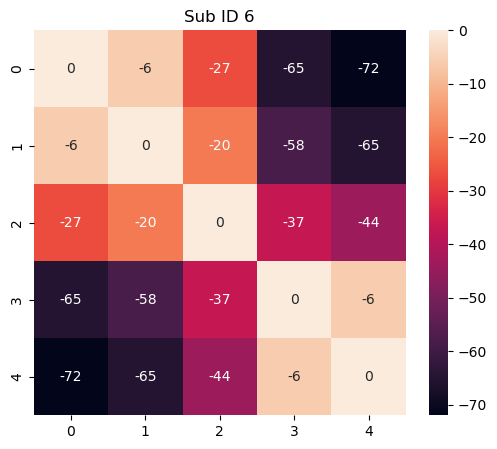

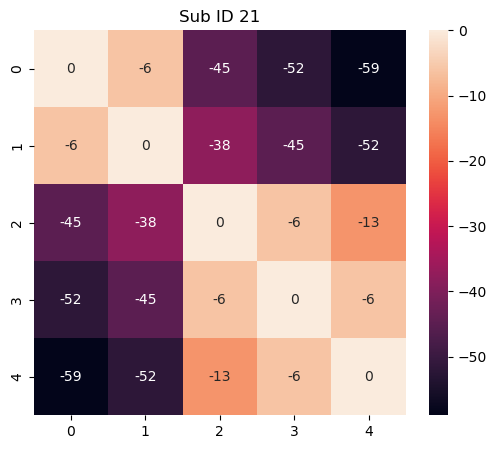

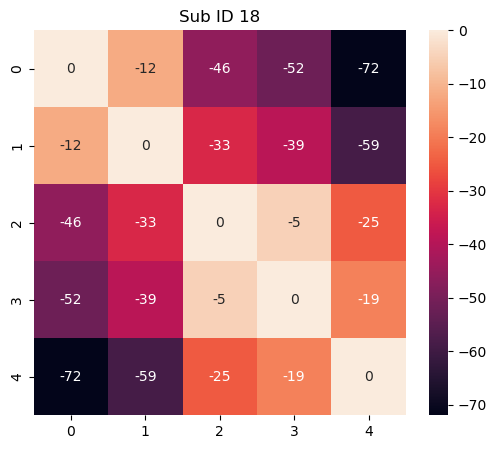

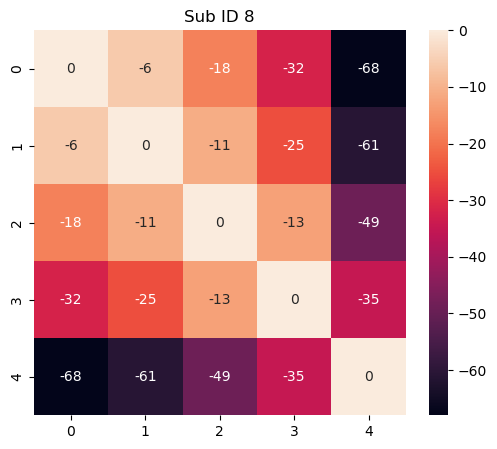

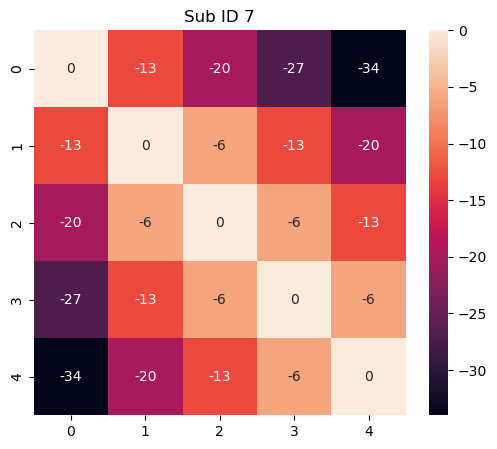

In [12]:
sub_time_session_similarity = np.zeros((20,5,5))

for x,sub_ID in enumerate(unique_subject_int):
    sub_time_stability = sub_time_gap_all[sub_time_gap_all['subNum'] == sub_ID]
    sub_time_stability.sort_values("session",inplace=True)
#     print(sub_big5_stability.iloc[:,:5])
#     if sub_ID == 36:
#         sub_big5_stability = sub_big5_stability.drop([154])
    
    sub_time_stability_items = sub_time_stability.iloc[:,0]
#     sub_time_stability_items = sub_time_stability_items.dropna(axis=1,how='any') 
    
    sub_time_stability_items_distance = np.zeros((5,5))
    for compare_time_1 in range(5):
        for compare_time_2 in range(5):
            sub_time_stability_items_distance[compare_time_1,compare_time_2] = int(float(sub_time_stability_items.iloc[compare_time_2]))-int(float(sub_time_stability_items.iloc[compare_time_1]))
    
    sub_time_stability_items_distance = Adjacency(sub_time_stability_items_distance, matrix_type="distance")
    sub_time_stability_items_similarity = Adjacency.distance_to_similarity(sub_time_stability_items_distance)
    sub_time_stability_items_similarity = sub_time_stability_items_similarity.squareform()
    
    sub_time_session_similarity[x,:,:] = sub_time_stability_items_similarity
    
    sub_fig, _ = plt.subplots(figsize=(6,5))
    sns.heatmap(sub_time_stability_items_similarity,annot=True).set(title = 'Sub ID ' + str(sub_ID) )


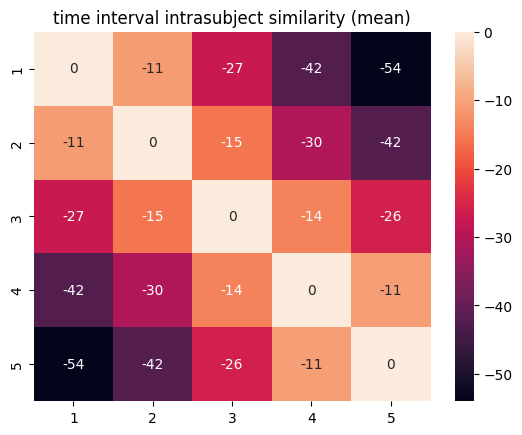

In [13]:
yticks = [1,2,3,4,5]
sns.heatmap(sub_time_session_similarity.mean(axis = 0),annot=True,yticklabels=yticks,xticklabels=yticks).set(title = 'time interval intrasubject similarity (mean)')
plt.savefig(os.path.join(current_directory,svg_file,"time_interval_intrasubject_similarity.svg"), format="svg")



nltools.data.brain_data.Brain_Data(data=(50, 238955), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)

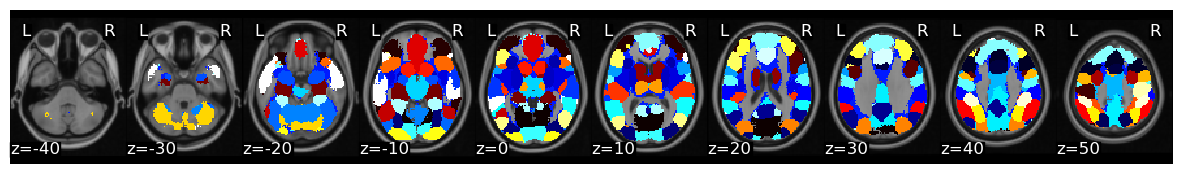

In [14]:
import os
from nltools.mask import expand_mask, roi_to_brain
from nltools.data import Brain_Data, Adjacency

# from fnl_tools.stats import (compute_ISC_all_roi,
#                              create_average_concordance)
from nltools.prefs import MNI_Template
import warnings
warnings.filterwarnings('ignore')

MNI_Template['resolution'] = '2mm' ## mask specify

base_dir = '/Storage/Data/nes/'

mask = Brain_Data(os.path.join(base_dir, 'code_menghan', 'Mask', 'k50_2mm.nii.gz'))
mask.plot()
#expand this mask into 50 separate regions
mask_x = expand_mask(mask) 
mask_x

## whole-brain temporal session-by-session similarity and real temporal distance

In [15]:

def temporal_ISC(roi_num):
    session_num = 5


    suball_movie_corr = pd.DataFrame()
    ISC_within_corr_all = []
    
    onset_movie = os.path.join('/Storage/Data/nes_menghan/', 'code_menghan', 'NeuroExperience','onset_movie.txt')
    onset_movie = pd.read_csv(onset_movie,sep='\t').set_index('Movie name')


    for sub_name in tqdm(subj_sids_iteration):
        data_subj_session = pd.DataFrame([])
        isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses*_Denoised_ROI_{roi_num}.csv"))
        isc_data.sort()
        for i in range(session_num):
            isc_data_session = pd.read_csv(isc_data[i])
            if len(data_subj_session) == 0:
                data_subj_session = isc_data_session
            else:
                data_subj_session = np.concatenate((data_subj_session,isc_data_session),axis = 1)

        video_corr = []
    #         video_corr_data = []
        for video_label in range(24):
            video_sess = []
            video_onset = onset_movie['Entire Onset'][video_label]-1
            video_end = onset_movie['Entire Ending'][video_label]-1
            video_sess = data_subj_session[video_onset:video_end+1,:] 

            video_data = pd.DataFrame(video_sess)
    #             video_data = video_data.T
            video_data_corr = video_data.corr()
            ISC_within_corr_all.append(video_data_corr.values.tolist())

    ISC_within_corr_all_np = np.array(ISC_within_corr_all)
    ISC_within_corr_all_np_reshape = ISC_within_corr_all_np.reshape(20,24,5,5)
    return ISC_within_corr_all_np_reshape

In [24]:
ROI_corr_time = []

onset_movie = os.path.join('/Storage/Data/nes_menghan/', 'code_menghan', 'NeuroExperience','onset_movie.txt')
onset_movie = pd.read_csv(onset_movie,sep='\t').set_index('Movie name')



for roi_num in range(50):
    ISC_within_corr_all_np_reshape = temporal_ISC(roi_num)
    corr_temporal = pd.DataFrame()
    
    for sub_id,sub_name in enumerate(subj_sids_iteration):
        for video_id in range(24):
            individual_pd_corr = pd.DataFrame()
            session_matrix = ISC_within_corr_all_np_reshape[sub_id,video_id,:,:]
            y_array_trail = session_matrix[np.triu_indices(5, 1)]


            sub_time_session_similarity_x = sub_time_session_similarity[sub_id,:,:]

            time_trail = sub_time_session_similarity_x[np.triu_indices(5, 1)]

            data = pd.DataFrame(np.array([time_trail,y_array_trail]).T,columns = ['time','temporal corr'])
            results_corr = data.corr().iloc[0,1]

            individual_pd_corr = pd.DataFrame(np.array([results_corr,sub_name,onset_movie.index[video_id]]).reshape((-1, 3)),columns = ['corr','participants','video'])


            corr_temporal = pd.concat([corr_temporal,individual_pd_corr])


        corr_temporal['corr']=corr_temporal['corr'].astype(float)
        
    ROI_corr_time.append(corr_temporal['corr'].mean())

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

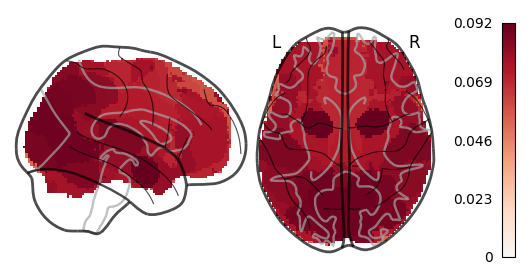

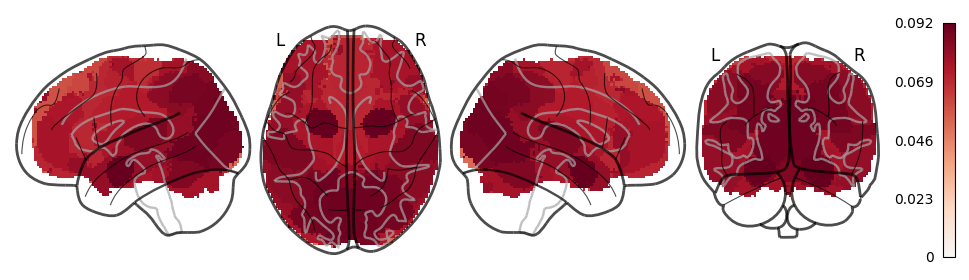

In [56]:
from nilearn.plotting import plot_glass_brain

ROI_corr_time_brain = roi_to_brain(ROI_corr_time, mask_x)

plot_glass_brain(ROI_corr_time_brain.to_nifti(), display_mode='xz',colorbar=True,cmap='RdBu_r',plot_abs=False)
plt.savefig(os.path.join(current_directory,svg_file,"time_interval_entire_brains_2.svg"), format="svg")
plot_glass_brain(ROI_corr_time_brain.to_nifti(), display_mode='lzry',colorbar=True,cmap='RdBu_r',plot_abs=False)
plt.savefig(os.path.join(current_directory,svg_file,"time_interval_entire_brains_4.svg"), format="svg")



### create repetition and proximity matrices by using temporal interval distances

In [27]:
sub_time_session_similarity.shape

(20, 5, 5)

In [16]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler(feature_range=(0, 1))

sub_time_session_auto = np.zeros((sub_time_session_similarity.shape))
sub_time_session_sess = np.zeros((sub_time_session_similarity.shape))
sub_time_session_sess_2 = np.zeros((sub_time_session_similarity.shape))

scaled_auto_array = np.zeros((5,5))
scaled_sess_array = np.zeros((5,5))
scaled_sess2_array = np.zeros((5,5))

for sub in range(20):
    
    sub_time_session_item = sub_time_session_similarity[sub,:,:]
    
    auto_list = np.array([sub_time_session_item.diagonal(1).mean(),sub_time_session_item.diagonal(2).mean(),sub_time_session_item.diagonal(3).mean(),sub_time_session_item.diagonal(4).mean()])
    sess_list = np.array([sub_time_session_item[1,0],sub_time_session_item[2,0],sub_time_session_item[3,0],sub_time_session_item[4,0]])
    sess_list_2 = np.array([sub_time_session_item[1:,0].mean(),sub_time_session_item[2:,1].mean(),sub_time_session_item[3:,2].mean(),sub_time_session_item[4:,3].mean()])


    scaled_auto_list = scaler.fit_transform([[x] for x in auto_list])
    scaled_sess_list = scaler.fit_transform([[y] for y in sess_list])
    scaled_sess_list_2 = scaler.fit_transform([[z] for z in sess_list_2])

    scaled_auto_array[[1,2,3,4],[0,1,2,3]] = scaled_auto_list[0][0]
    scaled_auto_array[[0,1,2,3],[1,2,3,4]] = scaled_auto_list[0][0]
    scaled_auto_array[[2,3,4],[0,1,2]] = scaled_auto_list[1][0]
    scaled_auto_array[[0,1,2],[2,3,4]] = scaled_auto_list[1][0]
    scaled_auto_array[[3,4],[0,1]] = scaled_auto_list[2][0]
    scaled_auto_array[[0,1],[3,4]] = scaled_auto_list[2][0]
    scaled_auto_array[[4],[0]] = scaled_auto_list[3][0]
    scaled_auto_array[[0],[4]] = scaled_auto_list[3][0]
    
    
    scaled_sess_array[1:,0] = scaled_sess_list[0][0]
    scaled_sess_array[0,1:] = scaled_sess_list[0][0]
    scaled_sess_array[2:,1] = scaled_sess_list[1][0]
    scaled_sess_array[1,2:] = scaled_sess_list[1][0]
    scaled_sess_array[3:,2] = scaled_sess_list[2][0]
    scaled_sess_array[2,3:] = scaled_sess_list[2][0]
    scaled_sess_array[4:,3] = scaled_sess_list[3][0]
    scaled_sess_array[3,4:] = scaled_sess_list[3][0]
    
    scaled_sess2_array[1:,0] = scaled_sess_list_2[0][0]
    scaled_sess2_array[0,1:] = scaled_sess_list_2[0][0]
    scaled_sess2_array[2:,1] = scaled_sess_list_2[1][0]
    scaled_sess2_array[1,2:] = scaled_sess_list_2[1][0]
    scaled_sess2_array[3:,2] = scaled_sess_list_2[2][0]
    scaled_sess2_array[2,3:] = scaled_sess_list_2[2][0]
    scaled_sess2_array[4:,3] = scaled_sess_list_2[3][0]
    scaled_sess2_array[3,4:] = scaled_sess_list_2[3][0]


                 
    sub_time_session_auto[sub,:,:] = scaled_auto_array
    sub_time_session_sess[sub,:,:] = scaled_sess_array
    sub_time_session_sess_2[sub,:,:] = scaled_sess2_array

In [17]:
dia = [0,1,2,3,4]
sub_time_session_auto[:,dia,dia] = np.nan
sub_time_session_sess[:,dia,dia] = np.nan
sub_time_session_sess_2[:,dia,dia] = np.nan



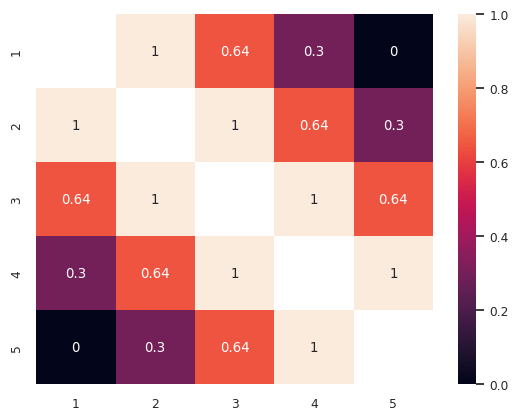

In [61]:
yticks = [1,2,3,4,5]
g = sns.heatmap(sub_time_session_auto.mean(axis = 0),annot=True,yticklabels=yticks,xticklabels=yticks)
g.set_facecolor('xkcd:white')
# plt.savefig(os.path.join(current_directory,svg_file,"time_interval_proximity.svg"), format="svg")

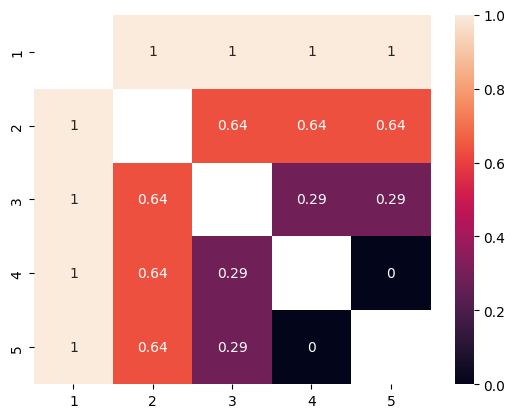

In [36]:
g = sns.heatmap(sub_time_session_sess.mean(axis = 0),annot=True,yticklabels=yticks,xticklabels=yticks)
g.set_facecolor('xkcd:white')
plt.savefig(os.path.join(current_directory,svg_file,"time_interval_repetition.svg"), format="svg")

<AxesSubplot: >

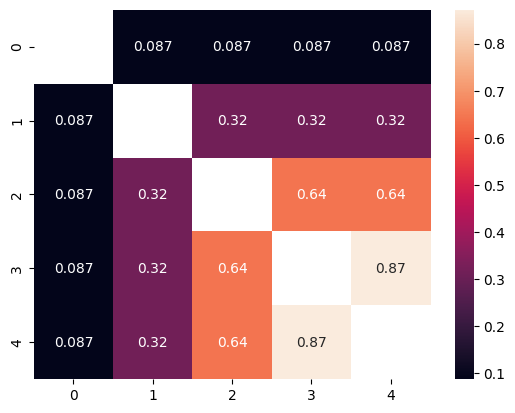

In [42]:
sns.heatmap(sub_time_session_sess_2.mean(axis = 0),annot=True)

## real time session and auto

In [50]:

roi_num = 4
session_num = 5

onset_movie = os.path.join('/Storage/Data/nes_menghan/', 'code_menghan', 'NeuroExperience','onset_movie.txt')
onset_movie = pd.read_csv(onset_movie,sep='\t').set_index('Movie name')

suball_movie_corr = pd.DataFrame()
ISC_within_corr_all_V1 = []


for sub_name in tqdm(subj_sids_iteration):
    data_subj_session = pd.DataFrame([])
    isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses*_Denoised_ROI_{roi_num}.csv"))
    isc_data.sort()
    for i in range(session_num):
        isc_data_session = pd.read_csv(isc_data[i])
        if len(data_subj_session) == 0:
            data_subj_session = isc_data_session
        else:
            data_subj_session = np.concatenate((data_subj_session,isc_data_session),axis = 1)

    video_corr = []
#         video_corr_data = []
    for video_label in range(24):
        video_sess = []
        video_onset = onset_movie['Entire Onset'][video_label]-1
        video_end = onset_movie['Entire Ending'][video_label]-1
        video_sess = data_subj_session[video_onset:video_end+1,:] 

        video_data = pd.DataFrame(video_sess)
#             video_data = video_data.T
        video_data_corr = video_data.corr()
        ISC_within_corr_all_V1.append(video_data_corr.values.tolist())

  0%|          | 0/20 [00:00<?, ?it/s]

In [51]:
ISC_within_corr_all_V1_np = np.array(ISC_within_corr_all_V1)
ISC_within_corr_all_V1_np_reshape = ISC_within_corr_all_V1_np.reshape(20,24,5,5)

In [52]:
import glob
from tqdm.notebook import tqdm
roi_num = 32
session_num = 5

onset_movie = os.path.join('/Storage/Data/nes_menghan/', 'code_menghan', 'NeuroExperience','onset_movie.txt')
onset_movie = pd.read_csv(onset_movie,sep='\t').set_index('Movie name')

suball_movie_corr = pd.DataFrame()
ISC_within_corr_all_Vmpfc = []


for sub_name in tqdm(subj_sids_iteration):
    data_subj_session = pd.DataFrame([])
    isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses*_Denoised_ROI_{roi_num}.csv"))
    isc_data.sort()
    for i in range(session_num):
        isc_data_session = pd.read_csv(isc_data[i])
        if len(data_subj_session) == 0:
            data_subj_session = isc_data_session
        else:
            data_subj_session = np.concatenate((data_subj_session,isc_data_session),axis = 1)

    video_corr = []
#         video_corr_data = []
    for video_label in range(24):
        video_sess = []
        video_onset = onset_movie['Entire Onset'][video_label]-1
        video_end = onset_movie['Entire Ending'][video_label]-1
        video_sess = data_subj_session[video_onset:video_end+1,:] 

        video_data = pd.DataFrame(video_sess)
#             video_data = video_data.T
        video_data_corr = video_data.corr()
        ISC_within_corr_all_Vmpfc.append(video_data_corr.values.tolist())

ISC_within_corr_all_Vmpfc_np = np.array(ISC_within_corr_all_Vmpfc)
ISC_within_corr_all_Vmpfc_np_reshape = ISC_within_corr_all_Vmpfc_np.reshape(20,24,5,5)

  0%|          | 0/20 [00:00<?, ?it/s]

In [53]:
import pingouin as pg

In [54]:
vmPFC_beta_temporal_mean = pd.DataFrame()
r2_vmPFC = []
        
for sub_id,sub_name in enumerate(subj_sids_iteration):
    
    session_matrix_zero = np.zeros((5,5))
    session_matrix_zero = session_matrix_zero[np.triu_indices(5, 1)]
    
    auto_matrix = sub_time_session_auto[sub_id,:,:]
    sess_matrix = sub_time_session_sess[sub_id,:,:]

    adj_trail = auto_matrix[np.triu_indices(5, 1)]
    repeat_trail = sess_matrix[np.triu_indices(5, 1)]
    
    for video_id in range(24):
        session_matrix = ISC_within_corr_all_Vmpfc_np_reshape[sub_id,video_id,:,:]
        y_array_trail = session_matrix[np.triu_indices(5, 1)]


        data = pd.DataFrame(np.array([adj_trail,repeat_trail,y_array_trail]).T,columns = ['Temporal Proximity','Viewing Repetition','temporal similarity'])
        results_linear_session_autocorr = pg.linear_regression(data.iloc[:,0:2],data['temporal similarity'])
        r2_vmPFC.append(results_linear_session_autocorr.iloc[0,5])

        individual_pd = results_linear_session_autocorr.iloc[1:3,0:2]
        individual_pd['participants'] = sub_name
        individual_pd['video'] = onset_movie.index[video_id]

        vmPFC_beta_temporal_mean = pd.concat([vmPFC_beta_temporal_mean,individual_pd])


    vmPFC_beta_temporal_mean['ROI'] = 'vmPFC'



        
        

In [55]:
V1_beta_temporal_mean = pd.DataFrame()
r2_V1 = []
        
for sub_id,sub_name in enumerate(subj_sids_iteration):
    
    session_matrix_zero = np.zeros((5,5))
    session_matrix_zero = session_matrix_zero[np.triu_indices(5, 1)]
   
    auto_matrix = sub_time_session_auto[sub_id,:,:]
    sess_matrix = sub_time_session_sess[sub_id,:,:]

    adj_trail = auto_matrix[np.triu_indices(5, 1)]
    repeat_trail = sess_matrix[np.triu_indices(5, 1)]
    
    for video_id in range(24):
        session_matrix = ISC_within_corr_all_V1_np_reshape[sub_id,video_id,:,:]
        y_array_trail = session_matrix[np.triu_indices(5, 1)]


        data = pd.DataFrame(np.array([adj_trail,repeat_trail,y_array_trail]).T,columns = ['Temporal Proximity','Viewing Repetition','temporal similarity'])
        results_linear_session_autocorr = pg.linear_regression(data.iloc[:,0:2],data['temporal similarity'])
        r2_V1.append(results_linear_session_autocorr.iloc[0,5])
        
        individual_pd = results_linear_session_autocorr.iloc[1:3,0:2]
        individual_pd['participants'] = sub_name
        individual_pd['video'] = onset_movie.index[video_id]

        V1_beta_temporal_mean = pd.concat([V1_beta_temporal_mean,individual_pd])


    V1_beta_temporal_mean['ROI'] = 'V1'



        
        

In [56]:
vmPFC_beta_temporal_mean['demeaned coef'] = vmPFC_beta_temporal_mean[['coef']]-vmPFC_beta_temporal_mean[['coef']].mean()
V1_beta_temporal_mean['demeaned coef'] = V1_beta_temporal_mean[['coef']]-V1_beta_temporal_mean[['coef']].mean()

In [57]:
ROI_beta_temporal_mean = pd.concat([vmPFC_beta_temporal_mean,V1_beta_temporal_mean])
ROI_beta_temporal_mean = ROI_beta_temporal_mean.rename(columns={'names':'effects'})

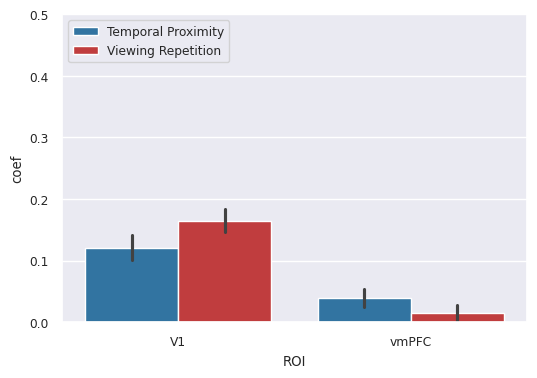

In [58]:
palette = ['tab:blue', 'tab:red']
order_list = ['V1', 'vmPFC']

plt.subplots(figsize=(6,4))
plt.ylim(0, 0.5)
sns.barplot(data=ROI_beta_temporal_mean,x = 'ROI', y="coef", hue="effects", palette=palette,order=order_list)
    # plt.legend(fontsize=10, title_fontsize='40')
plt.legend(loc = 'upper left')

# plt.savefig(os.path.join(current_directory,svg_file,"temporal_interval_effects_ROIs.svg"), format="svg")

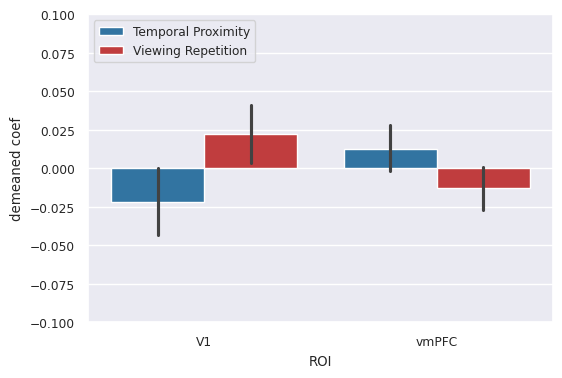

In [59]:
palette = ['tab:blue', 'tab:red']
order_list = ['V1', 'vmPFC']

plt.subplots(figsize=(6,4))
plt.ylim(-0.1, 0.1)
sns.barplot(data=ROI_beta_temporal_mean,x = 'ROI', y="demeaned coef", hue="effects", palette=palette,order=order_list)
    # plt.legend(fontsize=10, title_fontsize='40')
plt.legend(loc = 'upper left')

# plt.savefig(os.path.join(current_directory,svg_file,"temporal_interval_effects_ROIs_demeaned.svg"), format="svg")

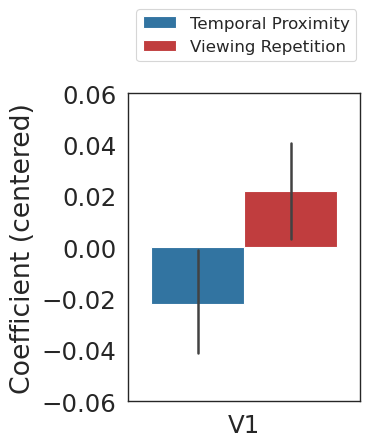

In [65]:
palette = ['tab:blue', 'tab:red']
with sns.plotting_context(context='paper',font_scale=2):
    plt.subplots(figsize=(3,4))
    plt.ylim(-0.06, 0.06)
    sns.set_style("whitegrid")
    sns.barplot(data=ROI_beta_temporal_mean[ROI_beta_temporal_mean['ROI'] == 'V1'],x = 'ROI', y="demeaned coef", hue="effects", palette=palette)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 1.3), fontsize=12)
    plt.xlabel('') 
    plt.ylabel("Coefficient (centered)")
    plt.savefig(os.path.join(current_directory,svg_file,"effects_ROIs_demean_V1_temporal.svg"), format="svg")


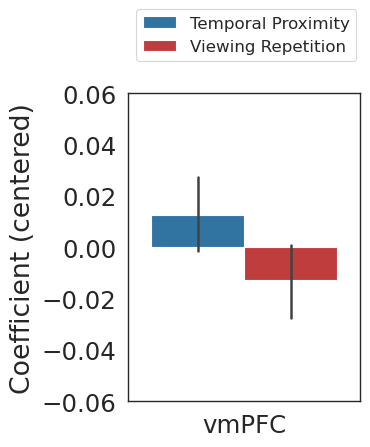

In [70]:
palette = ['tab:blue', 'tab:red']
with sns.plotting_context(context='paper',font_scale=2):
    plt.subplots(figsize=(3,4))
    plt.ylim(-0.06, 0.06)
    sns.set_style("white")
    sns.barplot(data=ROI_beta_temporal_mean[ROI_beta_temporal_mean['ROI'] == 'vmPFC'],x = 'ROI', y="demeaned coef", hue="effects", palette=palette)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 1.3), fontsize=12)
    plt.xlabel('') 
    plt.ylabel("Coefficient (centered)")
    plt.savefig(os.path.join(current_directory,svg_file,"effects_ROIs_demean_vmPFC_temporal.svg"), format="svg")


### Stats

In [95]:
ROI_beta_temporal_mean_rn = ROI_beta_temporal_mean.rename(columns={'demeaned coef': 'demeaned_coef'})
ROI_beta_temporal_mean_rn 

,effects,coef,participants,video,ROI,demeaned_coef
1,Temporal Proximity,-0.249638,sub-sid001377,Nature,vmPFC,-0.276915
2,Viewing Repetition,0.125962,sub-sid001377,Nature,vmPFC,0.098685
1,Temporal Proximity,0.015423,sub-sid001377,Asian cake,vmPFC,-0.011854
2,Viewing Repetition,0.131597,sub-sid001377,Asian cake,vmPFC,0.104320
1,Temporal Proximity,-0.186676,sub-sid001377,Ribbon climbing,vmPFC,-0.213953
...,...,...,...,...,...,...
2,Viewing Repetition,-0.022588,sub-sid000861,Russian,V1,-0.165737
1,Temporal Proximity,-0.080313,sub-sid000861,Burgers,V1,-0.223462
2,Viewing Repetition,-0.122975,sub-sid000861,Burgers,V1,-0.266124
1,Temporal Proximity,-0.119507,sub-sid000861,Ingrid Silva,V1,-0.262657


In [96]:
# Import the linear regression model class
from pymer4.models import Lmer

# Initialize model using 2 predictors and sample data
model = Lmer("demeaned_coef ~ effects*ROI + ( 1 | participants) + (1 | video)", data=ROI_beta_temporal_mean_rn)

# Fit it
print(model.fit(factors={"effects": ["Temporal Proximity", "Viewing Repetition"],"ROI": ["V1", "vmPFC"]}))

Linear mixed model fit by REML [’lmerMod’]
Formula: demeaned_coef~effects*ROI+(1|participants)+(1|video)

Family: gaussian	 Inference: parametric

Number of observations: 1920	 Groups: {'video': 24.0, 'participants': 20.0}

Log-likelihood: 446.061 	 AIC: -878.121

Random effects:

                     Name    Var    Std
video         (Intercept)  0.000  0.021
participants  (Intercept)  0.004  0.064
Residual                   0.035  0.187

No random effect correlations specified

Fixed effects:

               Estimate  2.5_ci  97.5_ci     SE       DF  T-stat  P-val  Sig
(Intercept)      -0.022  -0.056    0.012  0.017    32.51  -1.274  0.212     
effects1          0.044   0.020    0.068  0.012  1874.00   3.643  0.000  ***
ROI1              0.035   0.011    0.058  0.012  1874.00   2.873  0.004   **
effects1:ROI1    -0.069  -0.103   -0.036  0.017  1874.00  -4.064  0.000  ***


In [97]:
# Get ANOVA table, but this time force orthogonality
# for valid SS III inferences
# In this case the data are balanced so nothing changes
print(model.anova(force_orthogonal=True))

SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Model refit with orthogonal polynomial contrasts)
                       SS            MS  NumDF      DenomDF        F-stat  \
effects      4.153845e-02  4.153845e-02      1  1874.000003  1.183437e+00   
ROI          3.525539e-33  3.525539e-33      1  1874.000003  1.004432e-31   
effects:ROI  5.795886e-01  5.795886e-01      1  1874.000003  1.651258e+01   

                P-val  Sig  
effects      0.276797       
ROI          1.000000       
effects:ROI  0.000050  ***  


In [98]:
# Compute post-hoc tests with bonferroni correction
marginal_estimates, comparisons = model.post_hoc(
    marginal_vars="effects", grouping_vars=["ROI"], p_adjust="bonf"
)

# Pairwise comparisons
print(comparisons)

P-values adjusted by bonf method for 1 comparisons
                                  Contrast    ROI  Estimate  2.5_ci  97.5_ci  \
1  Temporal Proximity - Viewing Repetition     V1    -0.044  -0.068   -0.020   
2  Temporal Proximity - Viewing Repetition  vmPFC     0.025   0.002    0.049   

      SE      DF  T-stat  P-val  Sig  
1  0.012  1874.0  -3.643  0.000  ***  
2  0.012  1874.0   2.104  0.035    *  


### entire brain

In [36]:
from scipy import stats
import pingouin as pg
import numpy as np
from tqdm.notebook import tqdm
import glob

session_num = 5

onset_movie = os.path.join('/Storage/Data/nes_menghan/', 'code_menghan', 'NeuroExperience','onset_movie.txt')
onset_movie = pd.read_csv(onset_movie,sep='\t').set_index('Movie name')


roi_all = mask_x.data.shape[0]
Beta_session = []
Beta_autocorr = []


for roi_num in tqdm(range(roi_all)):
    ISC_within_corr_all = []
    for sub_name in tqdm(subj_sids_iteration):
        data_subj_session = pd.DataFrame([])
        isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses*_Denoised_ROI_{roi_num}.csv"))
        isc_data.sort()
        for i in range(session_num):
            isc_data_session = pd.read_csv(isc_data[i])
            if len(data_subj_session) == 0:
                data_subj_session = isc_data_session
            else:
                data_subj_session = np.concatenate((data_subj_session,isc_data_session),axis = 1)

        video_corr = []
    #         video_corr_data = []
        for video_label in range(24):
            video_sess = []
            video_onset = onset_movie['Entire Onset'][video_label]-1
            video_end = onset_movie['Entire Ending'][video_label]-1
            video_sess = data_subj_session[video_onset:video_end+1,:] 

            video_data = pd.DataFrame(video_sess)
    #             video_data = video_data.T
            video_data_corr = video_data.corr()
            ISC_within_corr_all.append(video_data_corr.values.tolist())
            
            
    ISC_within_corr_all_np = np.array(ISC_within_corr_all)
    ISC_within_corr_all_np_reshape = ISC_within_corr_all_np.reshape(20,24,5,5)
    
    ROI_beta_temporal_mean = pd.DataFrame([])
    for m in range(24):
        
        for n in range(20):
        
            session_matrix = ISC_within_corr_all_np_reshape[n,m,:,:]
                    
            sess_matrix = sub_time_session_auto[n,:,:]
            auto_matrix = sub_time_session_sess[n,:,:]


            sess_matrix_trail = sess_matrix[np.triu_indices(5, 1)]
            auto_matrix_trail = auto_matrix[np.triu_indices(5, 1)]

            y_array = session_matrix[np.triu_indices(5, 1)]

            data = pd.DataFrame(np.array([sess_matrix_trail,auto_matrix_trail,y_array]).reshape(3,-1).T,columns = ['Adjacency','Repeating','temporal corr'])
            results_linear_session_autocorr = pg.linear_regression(data.iloc[:,0:2], data['temporal corr'])

        
            individual_pd = results_linear_session_autocorr.iloc[1:3,0:2]
            individual_pd['participants'] = subj_sids_iteration[n]
            individual_pd['video'] = onset_movie.index[m]

            ROI_beta_temporal_mean = pd.concat([ROI_beta_temporal_mean,individual_pd])
   
    
    Beta_session.append(ROI_beta_temporal_mean[ROI_beta_temporal_mean['names'] == 'Repeating']['coef'].mean())
    Beta_autocorr.append(ROI_beta_temporal_mean[ROI_beta_temporal_mean['names'] == 'Adjacency']['coef'].mean())  

    

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [19]:
current_directory = '/Storage/Data/nes_menghan/code_menghan/NeuroExperience/'
svg_file = 'svg_files' ## svg plots

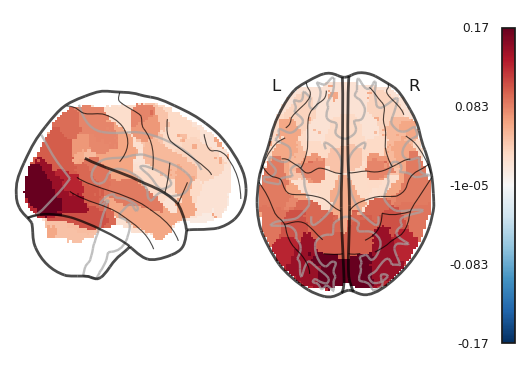

In [20]:
from nilearn.plotting import plot_glass_brain
import seaborn as sns

sns.set(font_scale=0.8)

Beta_session_brain = roi_to_brain(Beta_session, mask_x)
plot_glass_brain(Beta_session_brain.to_nifti(), display_mode='xz',colorbar=True,cmap='RdBu_r',plot_abs=False, symmetric_cbar=True)
plt.savefig(os.path.join(current_directory,svg_file,"time_interval_repetition_entire_brain.svg"), format="svg")

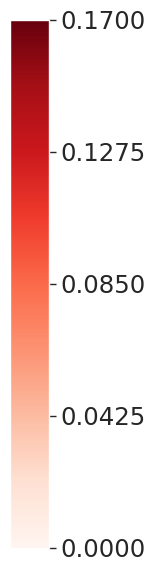

In [22]:

import matplotlib as mpl
with sns.plotting_context(context='paper', font_scale=2):
    fig, ax = plt.subplots(figsize=(0.5, 6))
    fig.subplots_adjust(bottom=0)

    cmap = mpl.cm.Reds
    norm = mpl.colors.Normalize(vmin=0, vmax=0.17)
    cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', ticks=np.linspace(0, 0.17, 5))
    plt.tight_layout()
    plt.savefig(os.path.join(current_directory,svg_file,"time_interval_repetition_entire_brain_cmap.svg"), format="svg")

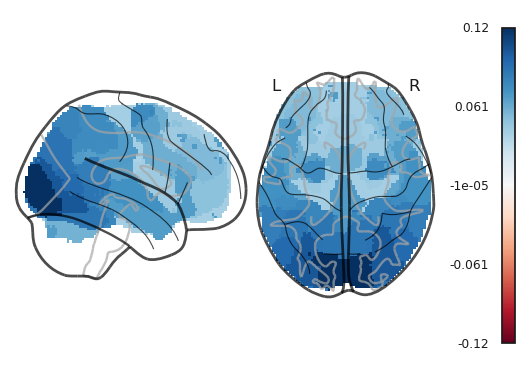

In [21]:
Beta_autocorr_brain = roi_to_brain(Beta_autocorr, mask_x)
plot_glass_brain(Beta_autocorr_brain.to_nifti(), display_mode='xz',colorbar=True,cmap='RdBu',plot_abs=False, symmetric_cbar=True)
plt.savefig(os.path.join(current_directory,svg_file,"time_interval_proximity_entire_brain.svg"), format="svg")

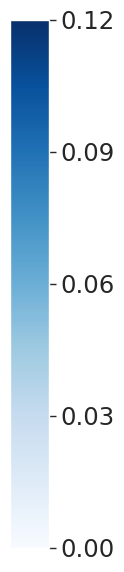

In [23]:

import matplotlib as mpl
with sns.plotting_context(context='paper', font_scale=2):
    fig, ax = plt.subplots(figsize=(0.5, 6))
    fig.subplots_adjust(bottom=0)

    cmap = mpl.cm.Blues
    norm = mpl.colors.Normalize(vmin=0, vmax=0.12)
    cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', ticks=np.linspace(0, 0.12, 5))
    plt.tight_layout()
    plt.savefig(os.path.join(current_directory,svg_file,"time_interval_proximity_entire_brain_cmap.svg"), format="svg")

In [37]:
from scipy import stats
import pingouin as pg
import numpy as np
from tqdm.notebook import tqdm
import glob

session_num = 5

onset_movie = os.path.join('/Storage/Data/nes_menghan/', 'code_menghan', 'NeuroExperience','onset_movie.txt')
onset_movie = pd.read_csv(onset_movie,sep='\t').set_index('Movie name')


roi_all = mask_x.data.shape[0]
Beta_session = pd.DataFrame()
Beta_autocorr = pd.DataFrame()




for roi_num in tqdm(range(roi_all)):
    ISC_within_corr_all = []
    for sub_name in tqdm(subj_sids_iteration):
        data_subj_session = pd.DataFrame([])
        isc_data = glob.glob(os.path.join('/Storage/Data/nes_menghan/denoised/Denoised_ROI',f"{sub_name}_ses*_Denoised_ROI_{roi_num}.csv"))
        isc_data.sort()
        for i in range(session_num):
            isc_data_session = pd.read_csv(isc_data[i])
            if len(data_subj_session) == 0:
                data_subj_session = isc_data_session
            else:
                data_subj_session = np.concatenate((data_subj_session,isc_data_session),axis = 1)

        video_corr = []
    #         video_corr_data = []
        for video_label in range(24):
            video_sess = []
            video_onset = onset_movie['Entire Onset'][video_label]-1
            video_end = onset_movie['Entire Ending'][video_label]-1
            video_sess = data_subj_session[video_onset:video_end+1,:] 

            video_data = pd.DataFrame(video_sess)
    #             video_data = video_data.T
            video_data_corr = video_data.corr()
            ISC_within_corr_all.append(video_data_corr.values.tolist())
            
            
    ISC_within_corr_all_np = np.array(ISC_within_corr_all)
    ISC_within_corr_all_np_reshape = ISC_within_corr_all_np.reshape(20,24,5,5)
    
    ROI_beta_temporal_mean = pd.DataFrame([])
    for m in range(24):
        
        for n in range(20):
        
            session_matrix = ISC_within_corr_all_np_reshape[n,m,:,:]
                    
            sess_matrix = sub_time_session_auto[n,:,:]
            auto_matrix = sub_time_session_sess[n,:,:]


            sess_matrix_trail = sess_matrix[np.triu_indices(5, 1)]
            auto_matrix_trail = auto_matrix[np.triu_indices(5, 1)]

            y_array = session_matrix[np.triu_indices(5, 1)]

            data = pd.DataFrame(np.array([sess_matrix_trail,auto_matrix_trail,y_array]).reshape(3,-1).T,columns = ['Adjacency','Repeating','temporal corr'])
            results_linear_session_autocorr = pg.linear_regression(data.iloc[:,0:2], data['temporal corr'])

        
            individual_pd = results_linear_session_autocorr.iloc[1:3,0:2]
            individual_pd['participants'] = subj_sids_iteration[n]
            individual_pd['video'] = onset_movie.index[m]

            ROI_beta_temporal_mean = pd.concat([ROI_beta_temporal_mean,individual_pd])
   
    
    Beta_session = pd.concat([Beta_session,ROI_beta_temporal_mean[ROI_beta_temporal_mean['names'] == 'Repeating'].groupby('participants')['coef'].mean()],axis = 1)
    Beta_autocorr = pd.concat([Beta_autocorr,ROI_beta_temporal_mean[ROI_beta_temporal_mean['names'] == 'Adjacency'].groupby('participants')['coef'].mean()],axis = 1)
  

    

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [38]:
from nltools.stats import (threshold, 
                           align,
                           fdr, 
                           isc,
                           _calc_pvalue)
from scipy import stats

roi_p = {}
for roi in range(50):
    roi_diff = Beta_session.iloc[:,roi]-Beta_autocorr.iloc[:,roi]
    roi_diff_t = stats.ttest_1samp(roi_diff,popmean = 0,alternative='two-sided')
    roi_p[roi] = roi_diff_t.pvalue

fdr_thr = fdr(np.array(list(roi_p.values())))
sig_roi = np.array(list(roi_p.keys()))[np.array(list(roi_p.values()) < np.array(0.05))]

In [46]:
fdr(np.array(list(roi_p.values())), 0.05)

-1

In [39]:
sig_roi

array([ 0,  4,  7, 12, 20, 25, 32, 34, 37, 43, 46])

In [44]:
roi_p

{0: 0.015153168447337167,
 1: 0.1633544344730885,
 2: 0.07026499129995462,
 3: 0.07231192251689089,
 4: 0.007279760310601754,
 5: 0.7340877517441575,
 6: 0.5166479376622188,
 7: 0.04355850590030466,
 8: 0.24473876748246318,
 9: 0.29206411297715723,
 10: 0.8703477001982194,
 11: 0.13526591395721432,
 12: 0.02774683241218851,
 13: 0.2895574581791815,
 14: 0.06328021693188426,
 15: 0.8784712779930283,
 16: 0.06799039423214853,
 17: 0.10842270187932289,
 18: 0.0602623132622557,
 19: 0.2245372989701112,
 20: 0.004721713001353096,
 21: 0.3546318760053353,
 22: 0.09422022692293479,
 23: 0.26761755253266734,
 24: 0.3207273105901426,
 25: 0.0118878817196547,
 26: 0.17285746183444795,
 27: 0.5524269447772627,
 28: 0.07095494322727812,
 29: 0.05180330730383991,
 30: 0.6191735821834168,
 31: 0.35485809864897755,
 32: 0.02417619905095715,
 33: 0.18385221013603725,
 34: 0.04482098308520153,
 35: 0.9009828139401623,
 36: 0.7133874890063863,
 37: 0.02632149642531246,
 38: 0.3017976809800619,
 39: 0.25

In [40]:
roi_diff_all = []
for roi in range(50):
    roi_diff = Beta_session.iloc[:,roi]-Beta_autocorr.iloc[:,roi]
    roi_diff_all.append(roi_diff.values.mean())
    

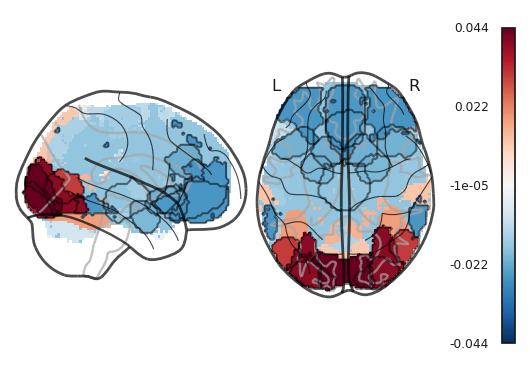

In [41]:
roi_diff_all_brain = roi_to_brain(roi_diff_all, mask_x)
display = plot_glass_brain(roi_diff_all_brain.to_nifti(), display_mode='xz',colorbar=True,cmap='RdBu_r',plot_abs=False, symmetric_cbar=True)

[display.add_contours(mask_x[x].to_nifti(), levels=[0.5], colors='black', alpha=.5) for x in sig_roi]
plt.savefig(os.path.join(current_directory,svg_file,"temporal_interval_entire_brain_difference.svg"), format="svg")

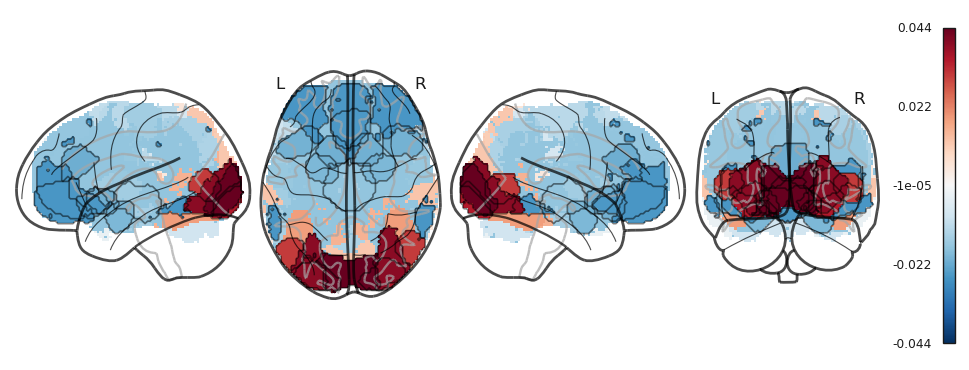

In [42]:
import matplotlib as mpl
with sns.plotting_context(context='paper', font_scale=1):
    roi_diff_all_brain = roi_to_brain(roi_diff_all, mask_x)
    display = plot_glass_brain(roi_diff_all_brain.to_nifti(), display_mode='lzry',colorbar=True,cmap='RdBu_r',plot_abs=False, symmetric_cbar=True)
    
    [display.add_contours(mask_x[x].to_nifti(), levels=[0.5], colors='black', alpha=.5) for x in sig_roi]
    plt.savefig(os.path.join(current_directory,svg_file,"temporal_interval_entire_brain_difference_all.svg"), format="svg")

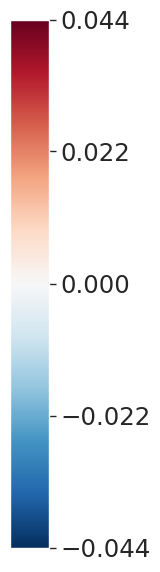

In [43]:
import matplotlib as mpl
with sns.plotting_context(context='paper', font_scale=2):
    fig, ax = plt.subplots(figsize=(0.5, 6))
    fig.subplots_adjust(bottom=0)

    cmap = mpl.cm.RdBu_r
    norm = mpl.colors.Normalize(vmin=-0.044, vmax=0.044)
    cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', ticks=np.linspace(-0.044, 0.044, 5))
    plt.tight_layout()
    plt.savefig(os.path.join(current_directory,svg_file,"temporal_interval_entire_brain_difference_all_cmap.svg"), format="svg")
    